# The window score: what it measures, and what the geometry masks do to it

## Scope

Series 0 defines the datasets. This series characterises the quantity every later
notebook computes from them — the window score — before any of them uses it to
predict something. Two properties of the score decide how its values may be
compared, and neither is obvious from its definition:

1. the score is a **sum over observable subsites**, so bonds near a terminus are
   not on the same scale as central ones;
2. the set of bonds that are scored at all is fixed by the **event geometry**, and
   using the wrong geometry does not merely add noise, it scores events the enzyme
   cannot perform.

The notebook measures both, on real peptides, and states what each one forbids.

## The score

For a bond $b$ of a peptide and a protease $\pi$,

$$S^{M}_{\pi,b} \;=\; \sum_{p\,:\,m_p=1} \Big( M_{\pi,p,a_p} \;-\; \log q_{a_p} \Big),$$

summed over the subsites $p$ the peptide actually occupies, with $a_p$ the residue
there, $M$ the smoothed log-probability of the MEROPS matrix and $q$ the residue
frequency of the human proteome. It is a **log-odds in nats**, not a
log-probability: a negative value means the residues at that bond are less likely
under the protease's profile than under the background, so the bond is actively
disfavoured rather than merely unobserved.

## Inputs and outputs

Inputs: `results/2_07_model_panel.csv`, `data/merops/`,
`data/reference/human_proteome/composition.json`, the APEX peptide table.

Outputs: `results/1_01_score_distribution.csv`,
`results/1_01_mask_effect.csv`, `results/1_01_geometry_effect.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_SUBSITES,
    EventGeometry,
    allowed_cut_positions,
    enumerate_window_scores,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
HUMAN_DATASET_ID = 34
N_PROBE_PEPTIDES = 200
PROBE_LENGTH_RANGE = (12, 30)
# Geometries compared against each protease's own, to measure what using the wrong
# one costs. The list is the set the model can express.
GEOMETRIES = (
    EventGeometry.ENDOPEPTIDASE,
    EventGeometry.AMINOPEPTIDASE,
    EventGeometry.CARBOXYPEPTIDASE,
    EventGeometry.DIPEPTIDYL_PEPTIDASE,
)
# A bond with fewer observable subsites than this is treated as terminal.
FULL_WINDOW_SUBSITES = len(MEROPS_SUBSITES)
SEED = common.SEED

In [3]:
rng = np.random.default_rng(SEED)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
matrices_panel = load_protease_panel(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = matrices_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(matrices_panel.codes)}
available = panel[panel["merops_code"].isin(index_of)].copy()

probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
)
probe = probe[probe["sequence"].str.len().between(*PROBE_LENGTH_RANGE)]
probe = probe.sample(n=min(N_PROBE_PEPTIDES, len(probe)), random_state=SEED)["sequence"].tolist()
print(f"proteases with a matrix: {len(available)} | probe peptides: {len(probe)}")

proteases with a matrix: 57 | probe peptides: 200


## What the score looks like

Every admissible bond of every probe peptide is scored under every panel protease
with its own geometry. The distribution is reported per protease rather than
pooled, because a protease with a sharp matrix and one with a flat matrix produce
scores on visibly different scales and pooling them would describe neither.

In [4]:
records = []
for row in available.itertuples():
    matrix = matrices[index_of[row.merops_code]]
    geometry = EventGeometry(row.event_geometry)
    for sequence in probe:
        scores, observed, admissible = enumerate_window_scores(
            sequence, matrix, geometry, human_background
        )
        for bond in np.flatnonzero(admissible & np.isfinite(scores)):
            records.append(
                {
                    "merops_code": row.merops_code,
                    "name": row.name,
                    "event_geometry": row.event_geometry,
                    "sequence_length": len(sequence),
                    "bond": int(bond),
                    "distance_to_terminus": int(min(bond, len(sequence) - 2 - bond)),
                    "n_observed_subsites": int(observed[bond]),
                    "score": float(scores[bond]),
                }
            )

scored = pd.DataFrame(records)
print(f"scored bonds: {len(scored):,}")
print()
print(scored["score"].describe()[["min", "25%", "50%", "75%", "max"]].round(2).to_string())
print(f"\nbonds with a negative score, i.e. actively disfavoured: "
      f"{int((scored['score'] < 0).sum()):,} ({(scored['score'] < 0).mean():.1%})")
print(f"bonds with a full {FULL_WINDOW_SUBSITES}-subsite window: "
      f"{int((scored['n_observed_subsites'] == FULL_WINDOW_SUBSITES).sum()):,} "
      f"({(scored['n_observed_subsites'] == FULL_WINDOW_SUBSITES).mean():.1%})")

distribution = (
    scored.groupby(["merops_code", "name", "event_geometry"])["score"]
    .agg(bonds="size", median="median", spread=lambda v: float(v.quantile(0.9) - v.quantile(0.1)))
    .reset_index()
    .sort_values("median", ascending=False)
)
print()
print(distribution.head(12).round(2).to_string(index=False))

scored bonds: 157,066

min   -22.37
25%    -4.77
50%    -2.72
75%    -0.87
max     9.85

bonds with a negative score, i.e. actively disfavoured: 132,699 (84.5%)
bonds with a full 8-subsite window: 99,866 (63.6%)

merops_code                                           name        event_geometry  bonds  median  spread
    C02.001                                      calpain-1         endopeptidase   3371   -0.40    3.76
    T01.013                      proteasome subunit beta1i         endopeptidase   3371   -0.78    3.65
    T01.015                      proteasome subunit beta5i         endopeptidase   3371   -0.79    3.99
    S53.003                        tripeptidyl-peptidase I tripeptidyl_peptidase    200   -0.92    6.90
    S09.018                         dipeptidyl-peptidase 8  dipeptidyl_peptidase    200   -1.41    4.04
    M10.009                     matrix metallopeptidase-12         endopeptidase   3371   -1.41    5.86
    S01.232                        t-plasminogen activator 

### Reading the figure

The left panel is the score distribution of each protease over the probe, ordered
by median: the vertical spread within one row is what the protease discriminates
between bonds, and the difference between rows is an offset that says nothing
about discrimination. The right panel is the same scores against how many subsites
the bond occupies, which is the first thing that has to be controlled before two
scores are compared.

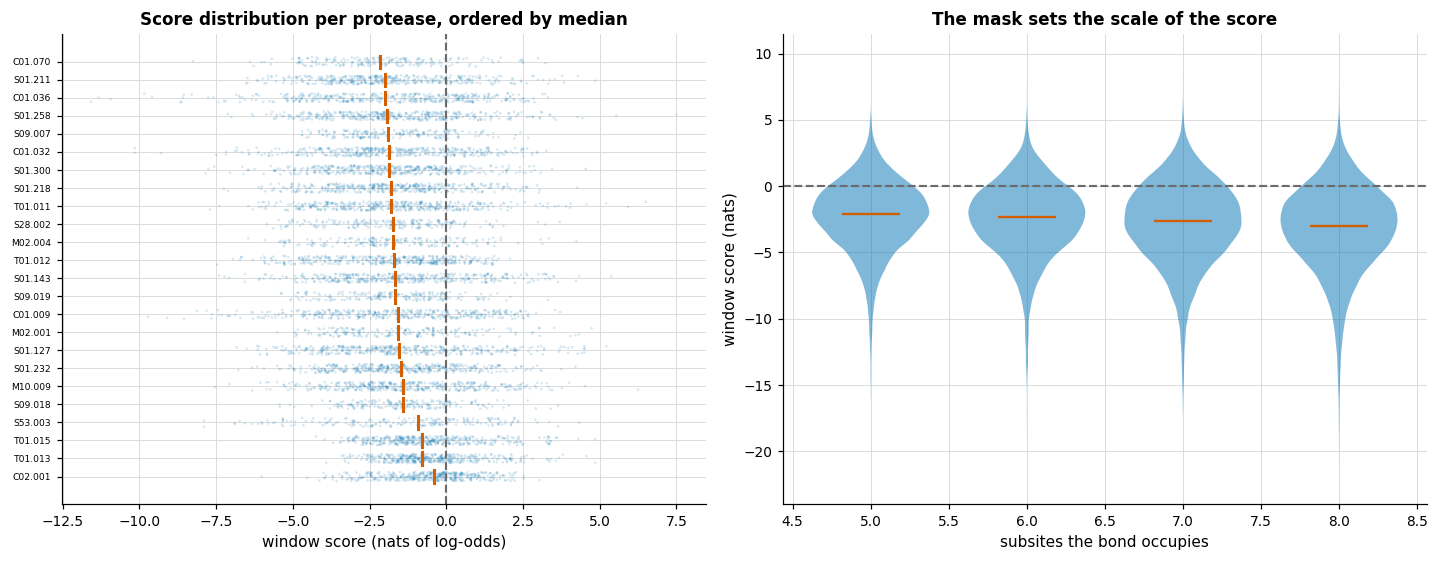

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))

ax = axes[0]
order = distribution["merops_code"].tolist()[:24]
for position, code in enumerate(order):
    values = scored.loc[scored["merops_code"] == code, "score"].to_numpy()
    sample = rng.choice(values, size=min(400, len(values)), replace=False)
    ax.scatter(sample, np.full(len(sample), position) + rng.uniform(-0.25, 0.25, len(sample)),
               s=3, color=common.CATEGORICAL_COLORS[0], alpha=0.16, edgecolor="none")
    ax.plot([np.median(values)] * 2, [position - 0.35, position + 0.35],
            color=common.CATEGORICAL_COLORS[1], linewidth=2.0, zorder=4)
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{c}" for c in order], fontsize=6)
ax.set_xlabel("window score (nats of log-odds)")
ax.set_title("Score distribution per protease, ordered by median")

ax = axes[1]
by_subsites = scored.groupby("n_observed_subsites")["score"]
positions = sorted(scored["n_observed_subsites"].unique())
data = [scored.loc[scored["n_observed_subsites"] == n, "score"].to_numpy() for n in positions]
parts = ax.violinplot(data, positions=positions, widths=0.75, showextrema=False, showmedians=True)
for body in parts["bodies"]:
    body.set_facecolor(common.CATEGORICAL_COLORS[0])
    body.set_alpha(0.5)
parts["cmedians"].set_color(common.CATEGORICAL_COLORS[1])
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_xlabel("subsites the bond occupies")
ax.set_ylabel("window score (nats)")
ax.set_title("The mask sets the scale of the score")

fig.tight_layout()
plt.show()

## The mask: why a terminal bond is not comparable to a central one

A bond three residues from the N terminus has no $P_4$, so its score is a sum over
seven terms where a central bond sums eight. The missing term is not zero in
expectation, and the direction of the bias is the opposite of what one might
expect: because most subsite contributions are **negative** — a randomly chosen
residue is usually less likely under a protease's profile than under the proteome
background — summing fewer of them produces a **less negative** total. A terminal
bond is therefore systematically **favoured** for its position rather than
penalised, and the argmax over bonds is biased toward the termini.

Two remedies are available and neither is free. **Masking**, which the model uses,
keeps the sum honest but leaves the scale dependent on position. **Per-subsite
normalisation**, dividing by the number of observed subsites, puts bonds on one
scale but changes the quantity from a log-odds into an average log-odds, which no
longer adds across subsites the way a likelihood does.

The size of the effect decides whether the choice matters.

In [6]:
mask_effect = (
    scored.groupby("n_observed_subsites")["score"]
    .agg(bonds="size", median="median", mean="mean")
    .reset_index()
)
mask_effect["per_subsite_median"] = mask_effect["median"] / mask_effect["n_observed_subsites"]
print(mask_effect.round(3).to_string(index=False))

full = scored[scored["n_observed_subsites"] == FULL_WINDOW_SUBSITES]["score"]
partial = scored[scored["n_observed_subsites"] < FULL_WINDOW_SUBSITES]["score"]
print(f"\nmedian score, full window:    {full.median():+.3f} nats")
print(f"median score, partial window: {partial.median():+.3f} nats")
print(f"difference:                   {full.median() - partial.median():+.3f} nats")

## Does the raw score rank a peptide's bonds by position rather than by residues?
position_bias = []
for code, group in scored.groupby("merops_code"):
    ## A geometry admitting a single bond gives every bond the same subsite count,
    ## so the correlation is undefined rather than zero and the protease is skipped.
    if group["n_observed_subsites"].nunique() < 2:
        continue
    correlation = spearmanr(group["n_observed_subsites"], group["score"]).statistic
    normalised = spearmanr(group["n_observed_subsites"], group["score"] / group["n_observed_subsites"]).statistic
    position_bias.append(
        {"merops_code": code, "raw_vs_subsites": float(correlation), "normalised_vs_subsites": float(normalised)}
    )
position_frame = pd.DataFrame(position_bias)
print()
print("correlation of the score with the number of observed subsites, over proteases:")
print(position_frame[["raw_vs_subsites", "normalised_vs_subsites"]].describe().loc[["mean", "50%"]].round(3).to_string())

 n_observed_subsites  bonds  median   mean  per_subsite_median
                   5  18600  -2.065 -2.279              -0.413
                   6  20000  -2.329 -2.536              -0.388
                   7  18600  -2.635 -2.844              -0.376
                   8  99866  -2.971 -3.257              -0.371

median score, full window:    -2.971 nats
median score, partial window: -2.317 nats
difference:                   -0.653 nats



correlation of the score with the number of observed subsites, over proteases:
      raw_vs_subsites  normalised_vs_subsites
mean           -0.137                   0.040
50%            -0.138                   0.018


## The geometry: which bonds exist at all

The geometry is not a preference, it is a constraint on the event. An
aminopeptidase removes a residue from the N terminus and cannot cut internally; a
carboxypeptidase does the same at the C terminus. Scoring the internal bonds of
a peptide under an aminopeptidase produces numbers for events the enzyme cannot
perform.

The first table is the size of the constraint: how many bonds each geometry admits
on a peptide of a given length. The second is the cost of getting it wrong,
measured as the share of a protease's own top-ranked bond that survives being
scored under a different geometry.

In [7]:
lengths = sorted({len(sequence) for sequence in probe})
admissible_counts = pd.DataFrame(
    [
        {
            "sequence_length": length,
            **{geometry.value: int(allowed_cut_positions(length, geometry).sum()) for geometry in GEOMETRIES},
        }
        for length in (min(lengths), int(np.median(lengths)), max(lengths))
    ]
)
print(admissible_counts.to_string(index=False))

geometry_records = []
for row in available.itertuples():
    own = EventGeometry(row.event_geometry)
    matrix = matrices[index_of[row.merops_code]]
    for geometry in GEOMETRIES:
        agreements, gaps = [], []
        for sequence in probe:
            own_scores, _, own_admissible = enumerate_window_scores(sequence, matrix, own, human_background)
            other_scores, _, other_admissible = enumerate_window_scores(sequence, matrix, geometry, human_background)
            if not own_admissible.any() or not other_admissible.any():
                continue
            own_top = int(np.argmax(np.where(own_admissible, own_scores, -np.inf)))
            other_top = int(np.argmax(np.where(other_admissible, other_scores, -np.inf)))
            agreements.append(own_top == other_top)
            gaps.append(float(own_scores[own_top] - other_scores[other_top]))
        if agreements:
            geometry_records.append(
                {
                    "merops_code": row.merops_code,
                    "own_geometry": row.event_geometry,
                    "scored_under": geometry.value,
                    "is_own": geometry == own,
                    "top_bond_agreement": float(np.mean(agreements)),
                    "median_score_gap_nats": float(np.median(gaps)),
                }
            )

geometry_effect = pd.DataFrame(geometry_records)
print()
print(
    geometry_effect[~geometry_effect["is_own"]]
    .groupby(["own_geometry", "scored_under"])[["top_bond_agreement", "median_score_gap_nats"]]
    .median()
    .round(3)
    .to_string()
)

 sequence_length  endopeptidase  aminopeptidase  carboxypeptidase  dipeptidyl_peptidase
              12             11               1                 1                     1
              18             17               1                 1                     1
              25             24               1                 1                     1



                                            top_bond_agreement  median_score_gap_nats
own_geometry          scored_under                                                   
aminopeptidase        carboxypeptidase                   0.000                 -2.215
                      dipeptidyl_peptidase               0.000                  0.232
                      endopeptidase                      0.075                 -3.285
dipeptidyl_peptidase  aminopeptidase                     0.000                 -0.373
                      carboxypeptidase                   0.000                 -0.624
                      endopeptidase                      0.068                 -2.948
endopeptidase         aminopeptidase                     0.090                  2.800
                      carboxypeptidase                   0.095                  3.122
                      dipeptidyl_peptidase               0.065                  3.165
peptidyl_dipeptidase  aminopeptidase                 

### Reading the figure

Rows are the geometry a protease actually has, columns the geometry it is scored
under. The diagonal is one by construction. An off-diagonal cell near one is a
pair of geometries that happen to nominate the same bond anyway; a cell near zero
is a pair where using the wrong geometry changes every decision, which is the case
the masks exist to prevent.

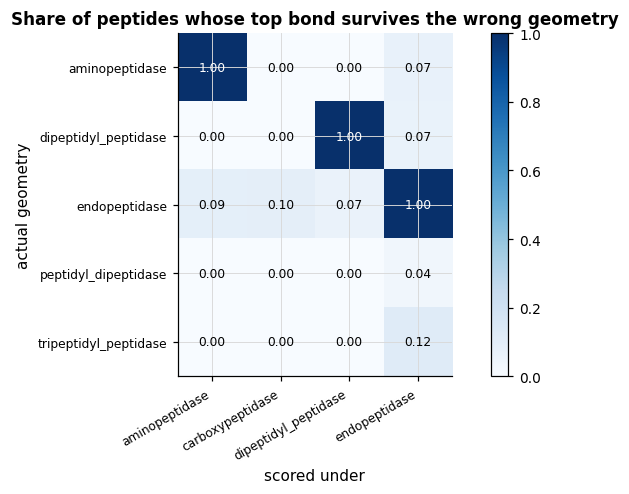

In [8]:
pivot = geometry_effect.pivot_table(
    index="own_geometry", columns="scored_under", values="top_bond_agreement", aggfunc="median"
)
fig, ax = plt.subplots(figsize=(7.6, 4.6))
image = ax.imshow(pivot.to_numpy(), vmin=0, vmax=1, cmap=common.SEQUENTIAL_CMAP)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.to_numpy()[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if value > 0.55 else "black")
ax.set_xlabel("scored under")
ax.set_ylabel("actual geometry")
ax.set_title("Share of peptides whose top bond survives the wrong geometry")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

In [9]:
common.save_result(distribution, "1_01_score_distribution.csv")
common.save_result(mask_effect, "1_01_mask_effect.csv")
common.save_result(geometry_effect, "1_01_geometry_effect.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/1_01_geometry_effect.csv')

## Findings and decisions


**The score is a log-odds, and 84.5% of scored bonds are negative.** The median
bond scores $-2.72$ nats. That is not a defect: a randomly chosen bond of a random
peptide *should* be disfavoured relative to the proteome background, and the score
is mostly telling the model where **not** to cut. Any downstream treatment that
clips scores at zero, or reads them as probabilities, throws that away.

**The mask favours terminal bonds, which is the opposite of the intuitive
expectation and is a bias in the model's own argmax.**

| subsites occupied | bonds | median score |
| --- | --- | --- |
| 5 | 18 600 | $-2.065$ |
| 6 | 20 000 | $-2.329$ |
| 7 | 18 600 | $-2.635$ |
| 8 | 99 866 | $-2.971$ |

A full eight-subsite window scores **0.65 nats lower** than a partial one, and the
correlation between the score and the number of observed subsites is $-0.137$ over
proteases. The mechanism is the previous point: most subsite contributions are
negative, so a shorter sum is a larger score. Per-subsite normalisation removes
almost all of it, taking the correlation to $+0.04$.

This is a real bias in `first_cut_distribution`, which takes a softmax over bonds
within a peptide: terminal bonds carry a systematic advantage of roughly two thirds
of a nat, which at the fitted slope is not negligible. It is not corrected here,
because per-subsite normalisation converts a log-odds into an average log-odds that
can no longer be exponentiated into an intensity, and the alternative — imputing the
missing subsites from the background — would assert observations that were not made.
It is recorded as a known bias, and `3_02` is the notebook that already controls for
it, which is why its position control is not decoration.

**Geometry is a hard constraint and the confusion matrix is close to degenerate.**
Scoring a protease under a geometry other than its own leaves the nominated bond
unchanged in **0% to 9.5%** of peptides. An endopeptidase admits 11 bonds on a
12-residue peptide and 24 on a 25-residue one, while an aminopeptidase,
carboxypeptidase or dipeptidyl-peptidase admits exactly one — so the wrong geometry
does not perturb a decision, it replaces it with a different decision entirely, for
an event the enzyme cannot perform.

That is why `EC_NUMBER_GEOMETRY` carries exact overrides for the EC sub-subclasses
that mix geometries, and why TPP1 being typed as dipeptidyl by the sub-subclass rule
alone was a defect worth a special case rather than a rounding error: it was not
shifting a score, it was scoring the wrong event.